# Step 2 — Build the Case-Step Feature Table

This notebook completes **Step 2 only**.

Goal: create one row per event-in-case, with time, sequence, and branch features for RL.

## What this notebook does

1. Load all municipality logs.
2. Load the Step 1 graph priors file.
3. Build ordered event traces for each application case.
4. Create one feature row for each event step.
5. Save the feature table for later steps.

In [10]:
%pip install pandas pyarrow openpyxl matplotlib scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 373.0 kB/s eta 0:00:0000:0100:04
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import json
from pathlib import Path
from collections import defaultdict

import pandas as pd

DATASET_DIR = Path('./dataset')
OUTPUT_DIR = Path('./output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRIORS_PATH = OUTPUT_DIR / 'graph_priors.json'
MUNICIPALITIES = [1, 2, 3, 4, 5]

print('Dataset dir:', DATASET_DIR.resolve())
print('Output dir :', OUTPUT_DIR.resolve())
print('Priors file:', PRIORS_PATH.resolve())

Dataset dir: /home/praharsha/Desktop/bueracratic-workflow-analyzer/dataset
Output dir : /home/praharsha/Desktop/bueracratic-workflow-analyzer/output
Priors file: /home/praharsha/Desktop/bueracratic-workflow-analyzer/output/graph_priors.json


In [12]:
def load_ocel(path: Path) -> dict:
    with open(path, 'r') as f:
        return json.load(f)

if not PRIORS_PATH.exists():
    print('Error: previous notebook should be run first (Step 1 missing graph_priors.json).')
    raise SystemExit(1)

with open(PRIORS_PATH, 'r') as f:
    priors = json.load(f)

logs = {}
for m in MUNICIPALITIES:
    path = DATASET_DIR / f'BPIC15_Municipality{m}.jsonocel'
    logs[m] = load_ocel(path)
    event_count = len(logs[m]['ocel:events'])
    print(f'M{m}: {event_count:,} events loaded')

print('Loaded priors keys:', list(priors.keys()))

M1: 52,217 events loaded
M2: 44,354 events loaded
M3: 59,681 events loaded
M4: 47,293 events loaded
M5: 59,083 events loaded
Loaded priors keys: ['config', 'backbone_edges', 'rare_edges_by_municipality', 'top_transitions_by_municipality', 'activity_rank_by_municipality']


## Helper functions

This section builds helper functions to:
- group events into ordered case traces,
- map branch edges from priors,
- infer branch labels and case completion.

In [13]:
# Builds case event sequences for each municipality
# Groups events by case (object of type 'Application') and sort them by timestamp
# It outputs a dict of case_id -> list of events, where each event is a dict with keys: event_id, timestamp, activity
def build_case_event_sequences(log: dict, object_type: str = 'Application'):
    events = log['ocel:events']
    objects = log['ocel:objects']

    case_ids = {oid for oid, obj in objects.items() if obj['ocel:type'] == object_type}

    by_case = defaultdict(list)
    for event_id, event in events.items():
        ts = pd.to_datetime(event['ocel:timestamp'], utc=True, errors='coerce')
        act = event['ocel:activity']
        related_cases = [oid for oid in event.get('ocel:omap', []) if oid in case_ids]
        for case_id in related_cases:
            by_case[case_id].append({
                'event_id': event_id,
                'timestamp': ts,
                'activity': act
            })

    for case_id in by_case:
        by_case[case_id].sort(key=lambda x: x['timestamp'])

    return by_case

# Builds a lookup for activity ranks by municipality
# Ranks activities by their frequency in the municipality graph priors
# It outputs a dict of municipality -> dict of activity -> rank (float)
def build_stage_rank_lookup(priors_dict: dict):
    stage_lookup = {}
    rank_map = priors_dict.get('activity_rank_by_municipality', {})
    for m_str, activity_map in rank_map.items():
        m = int(m_str)
        stage_lookup[m] = {a: float(r) for a, r in activity_map.items()}
    return stage_lookup

# Builds municipality-specific rare-edge sets and one backbone set
# Rare edges MUST stay municipality-specific (no cross-municipality union)
def build_branch_edge_sets(priors_dict: dict):
    rare_by_m_raw = priors_dict.get('rare_edges_by_municipality', {})

    rare_by_municipality = {}
    for m_str, edges in rare_by_m_raw.items():
        m = int(m_str)
        rare_by_municipality[m] = {
            (edge['src'], edge['tgt'])
            for edge in edges
        }

    backbone = set()
    for edge in priors_dict.get('backbone_edges', []):
        backbone.add((edge['src'], edge['tgt']))

    return rare_by_municipality, backbone

In [21]:
from collections import defaultdict

BRANCH_REFUSAL_TERMS = [
    'refusal',
    'no permit needed',
    'objection lodged',
    'grounds for refusal',
    'grounds refusal',
    'wabo applies',
    'article 34',
    'refusal reassessment',
    'plan refusal',
]

BRANCH_SUSPENSION_TERMS = [
    'suspension',
    'suspend term',
    'extend procedure',
    'permanent suspension',
    'irrevocable suspension',
    'suspension date',
    'suspension copy',
    'suspension objection',
]

BRANCH_COMPLETENESS_TERMS = [
    'completeness',
    'subcases content',
    'subcases completed',
    'resume completeness',
    'request complete',
    'send procedure confirmation',
]

CASE_COMPLETED_TERMS = [
    'close case',
    'phase archived',
    'terminate on request',
    'irrevocable',
    'decision permitting sent',
    'decision environmental permit',
    'publication decision environmental permit',
    'record date of decision environmental permit',
    'set phase decision revoked',
    'decision permanent suspension',
]

CASE_NOT_COMPLETED_TERMS = [
    'objection lodged',
    'retrieve missing data',
    'acknowledgement',
    'register deadline',
    'date decision for inspection',
    'create publication document',
    'generate publication document',
    'send confirmation receipt',
]

BRANCH_TERMS = {
    'refusal': BRANCH_REFUSAL_TERMS,
    'suspension': BRANCH_SUSPENSION_TERMS,
    'completeness': BRANCH_COMPLETENESS_TERMS,
}


def _normalize_text(text: str) -> str:
    return (text or '').strip().lower()


def labels_from_text(text: str):
    normalized = _normalize_text(text)
    return {
        label
        for label, terms in BRANCH_TERMS.items()
        if any(term in normalized for term in terms)
    }


def build_edge_branch_model(case_sequences, lookahead: int = 3, min_support: int = 25, purity_threshold: float = 0.7):
    edge_label_counts = defaultdict(lambda: defaultdict(int))
    source_nexts = defaultdict(set)

    for events in case_sequences.values():
        n = len(events)
        for i in range(n - 1):
            src = events[i]['activity']
            tgt = events[i + 1]['activity']
            edge = (src, tgt)
            source_nexts[src].add(tgt)

            horizon = events[i:min(i + lookahead + 1, n)]
            labels = set()
            for ev in horizon:
                labels |= labels_from_text(ev['activity'])

            for label in labels:
                edge_label_counts[edge][label] += 1

    edge_branch_model = {}
    for edge, label_counts in edge_label_counts.items():
        src = edge[0]
        if len(source_nexts[src]) < 2:
            continue

        total = sum(label_counts.values())
        if total < min_support:
            continue

        best_label = max(label_counts, key=label_counts.get)
        purity = label_counts[best_label] / total
        if purity >= purity_threshold:
            edge_branch_model[edge] = {
                'label': best_label,
                'confidence': float(purity),
                'support': int(total)
            }

    return edge_branch_model


def infer_branch_label_for_step(events, step_index: int, edge_branch_model: dict, lookahead: int = 3):
    curr = events[step_index]['activity']
    next_activity = events[step_index + 1]['activity'] if step_index < len(events) - 1 else None
    edge = (curr, next_activity) if next_activity is not None else None

    if edge is not None and edge in edge_branch_model:
        model_entry = edge_branch_model[edge]
        return model_entry['label'], float(model_entry['confidence']), 'edge_model'

    horizon = events[step_index:min(step_index + lookahead + 1, len(events))]
    votes = defaultdict(float)

    for dist, ev in enumerate(horizon):
        weight = 1.0 / (1.0 + dist)
        labels = labels_from_text(ev['activity'])
        for label in labels:
            votes[label] += weight

    if not votes:
        return 'unknown', 0.0, 'none'

    best_label = max(votes, key=votes.get)
    total_votes = sum(votes.values())
    confidence = float(votes[best_label] / total_votes) if total_votes > 0 else 0.0

    if confidence < 0.55:
        return 'unknown', confidence, 'lookahead_ambiguous'

    return best_label, confidence, 'lookahead'


def case_completed_heuristic(last_activity: str) -> bool:
    text = _normalize_text(last_activity)

    if any(term in text for term in CASE_NOT_COMPLETED_TERMS):
        return False

    if any(term in text for term in CASE_COMPLETED_TERMS):
        return True

    return False

## Build case-step rows

Each row is one event step in a case trace.

In [22]:
stage_rank_lookup = build_stage_rank_lookup(priors)
rare_edges_by_municipality, backbone_edges = build_branch_edge_sets(priors)

# Pre-build sequences once per municipality for reuse
case_sequences_by_m = {m: build_case_event_sequences(logs[m]) for m in MUNICIPALITIES}

# Learn edge->branch models per municipality (decision-point transitions only)
edge_branch_models = {}
for m in MUNICIPALITIES:
    edge_branch_models[m] = build_edge_branch_model(
        case_sequences_by_m[m],
        lookahead=3,
        min_support=25,
        purity_threshold=0.70
    )
    print(f'M{m}: learned {len(edge_branch_models[m])} branch-labeled transition edges')

rows = []

for m in MUNICIPALITIES:
    case_sequences = case_sequences_by_m[m]
    ranks = stage_rank_lookup.get(m, {})
    rare_edges_for_m = rare_edges_by_municipality.get(m, set())
    edge_branch_model = edge_branch_models[m]

    for case_id, events in case_sequences.items():
        if not events:
            continue

        case_start = events[0]['timestamp']
        trace_length = len(events)
        activity_seen_count = defaultdict(int)

        last_activity = events[-1]['activity']
        case_will_complete = case_completed_heuristic(last_activity)

        for i, ev in enumerate(events):
            curr_activity = ev['activity']
            curr_ts = ev['timestamp']

            prev_activity = events[i - 1]['activity'] if i > 0 else None
            next_activity = events[i + 1]['activity'] if i < (trace_length - 1) else None

            prev_ts = events[i - 1]['timestamp'] if i > 0 else None
            delta_case_hours = (curr_ts - case_start).total_seconds() / 3600.0
            delta_prev_hours = ((curr_ts - prev_ts).total_seconds() / 3600.0) if prev_ts is not None else 0.0

            transition_edge = (curr_activity, next_activity) if next_activity is not None else None
            is_rare_edge = transition_edge in rare_edges_for_m if transition_edge else False
            is_backbone_edge = transition_edge in backbone_edges if transition_edge else False

            seen_before = activity_seen_count[curr_activity] > 0
            rework_count_activity = activity_seen_count[curr_activity]
            activity_seen_count[curr_activity] += 1

            (
                branch_label,
                branch_confidence,
                branch_source,
            ) = infer_branch_label_for_step(
                events=events,
                step_index=i,
                edge_branch_model=edge_branch_model,
                lookahead=3
            )

            is_refusal_path = bool(branch_label == 'refusal')
            is_suspension_path = bool(branch_label == 'suspension')
            is_completeness_path = bool(branch_label == 'completeness')

            is_terminal_event = bool(i == trace_length - 1)

            rows.append({
                'municipality': m,
                'case_id': case_id,
                'event_id': ev['event_id'],
                'timestamp': curr_ts,
                'activity': curr_activity,
                'prev_activity': prev_activity,
                'next_activity': next_activity,
                'step_index': i,
                'trace_length': trace_length,
                'stage_rank': ranks.get(curr_activity, 0.5),
                'time_since_case_start_hours': max(delta_case_hours, 0.0),
                'time_since_prev_hours': max(delta_prev_hours, 0.0),
                'rework_count_activity': rework_count_activity,
                'seen_activity_before': bool(seen_before),
                'is_rare_transition_to_next': bool(is_rare_edge),
                'is_backbone_transition_to_next': bool(is_backbone_edge),
                'branch_label': branch_label,
                'branch_confidence': float(branch_confidence),
                'branch_source': branch_source,
                'is_refusal_path': is_refusal_path,
                'is_suspension_path': is_suspension_path,
                'is_completeness_path': is_completeness_path,
                'is_unknown_branch': bool(branch_label == 'unknown'),
                'is_terminal_event': is_terminal_event,
                'case_will_complete': bool(case_will_complete),
                'case_completed': bool(is_terminal_event and case_will_complete)
            })

features_df = pd.DataFrame(rows).sort_values(['municipality', 'case_id', 'timestamp', 'event_id']).reset_index(drop=True)

print('Rows:', len(features_df))
print('Columns:', len(features_df.columns))
print('Branch label distribution:')
print(features_df['branch_label'].value_counts(dropna=False).to_string())
features_df.head(5)

M1: learned 129 branch-labeled transition edges
M2: learned 124 branch-labeled transition edges
M3: learned 121 branch-labeled transition edges
M4: learned 133 branch-labeled transition edges
M5: learned 167 branch-labeled transition edges
Rows: 262628
Columns: 26
Branch label distribution:
branch_label
unknown         111513
completeness     91500
refusal          36918
suspension       22697


,municipality,case_id,event_id,timestamp,activity,prev_activity,next_activity,step_index,trace_length,stage_rank,...,branch_label,branch_confidence,branch_source,is_refusal_path,is_suspension_path,is_completeness_path,is_unknown_branch,is_terminal_event,case_will_complete,case_completed
0,1,44688,268496,2011-07-08 00:00:00+00:00,register submission date request,NaN,phase application received,0,43,0.009373,...,unknown,0.0,none,False,False,False,True,False,False,False
1,1,44688,268497,2011-07-18 08:59:43+00:00,phase application received,register submission date request,terminate on request,1,43,0.144496,...,refusal,1.0,lookahead,True,False,False,False,False,False,False
2,1,44688,268498,2011-07-18 08:59:50+00:00,terminate on request,phase application received,applicant is stakeholder,2,43,0.358921,...,refusal,1.0,lookahead,True,False,False,False,False,False,False
3,1,44688,268499,2011-07-18 08:59:55+00:00,applicant is stakeholder,terminate on request,no permit needed or only notification needed,3,43,0.340811,...,refusal,1.0,lookahead,True,False,False,False,False,False,False
4,1,44688,268500,2011-07-18 09:00:02+00:00,no permit needed or only notification needed,applicant is stakeholder,send confirmation receipt,4,43,0.261181,...,refusal,1.0,lookahead,True,False,False,False,False,False,False


## Hybrid branch labeling

Rules:
- Keep heuristic labels for high-confidence edge predictions (`branch_source == 'edge_model'` and `branch_confidence > 0.85`).
- Re-predict low-confidence or unclear rows with a small supervised model.
- Save final outputs in `branch_label_final`, `branch_confidence_final`, and `branch_source_final`.

In [23]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ---------- Training candidates from high-confidence heuristic labels ----------
train_mask = (
    (features_df['branch_label'] != 'unknown')
    & (features_df['branch_source'] == 'edge_model')
    & (features_df['branch_confidence'] >= 0.70)
)

fallback_mask = (
    (features_df['branch_label'] == 'unknown')
    | (features_df['branch_confidence'] < 0.85)
    | (features_df['branch_source'].isin(['lookahead_ambiguous', 'none']))
)

features_df['step_position_ratio'] = np.where(
    features_df['trace_length'] > 1,
    features_df['step_index'] / (features_df['trace_length'] - 1),
    0.0
)

features_df['activity_text'] = features_df['activity'].fillna('')
features_df['prev_activity_text'] = features_df['prev_activity'].fillna('')
features_df['next_activity_text'] = features_df['next_activity'].fillna('')

text_cols = ['activity_text', 'prev_activity_text', 'next_activity_text']
numeric_cols = [
    'step_index',
    'trace_length',
    'step_position_ratio',
    'time_since_case_start_hours',
    'time_since_prev_hours',
    'rework_count_activity',
    'stage_rank',
]
categorical_cols = ['municipality']

X_train = features_df.loc[train_mask, text_cols + numeric_cols + categorical_cols].copy()
y_train = features_df.loc[train_mask, 'branch_label'].copy()

hybrid_model = None
if len(X_train) >= 1000 and y_train.nunique() >= 2:
    preprocess = ColumnTransformer(
        transformers=[
            (
                'activity_tfidf',
                TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=1200),
                'activity_text',
            ),
            (
                'prev_tfidf',
                TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=700),
                'prev_activity_text',
            ),
            (
                'next_tfidf',
                TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_features=700),
                'next_activity_text',
            ),
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler(with_mean=False)),
                ]),
                numeric_cols,
            ),
            (
                'cat',
                OneHotEncoder(handle_unknown='ignore'),
                categorical_cols,
            ),
        ],
        sparse_threshold=0.3,
    )

    hybrid_model = Pipeline([
        ('preprocess', preprocess),
        ('clf', LogisticRegression(max_iter=400, class_weight='balanced', random_state=42)),
    ])

    hybrid_model.fit(X_train, y_train)
    print(f'Hybrid model trained on {len(X_train):,} rows | labels: {sorted(y_train.unique().tolist())}')
else:
    print('Hybrid model skipped: not enough high-confidence training data.')

# ---------- Apply hybrid policy ----------
features_df['branch_label_final'] = features_df['branch_label']
features_df['branch_confidence_final'] = features_df['branch_confidence'].astype(float)
features_df['branch_source_final'] = features_df['branch_source']

if hybrid_model is not None:
    X_fallback = features_df.loc[fallback_mask, text_cols + numeric_cols + categorical_cols].copy()
    if len(X_fallback) > 0:
        pred = hybrid_model.predict(X_fallback)
        pred_proba = hybrid_model.predict_proba(X_fallback)
        pred_conf = pred_proba.max(axis=1)

        confidence_gate = 0.60
        accepted = pred_conf >= confidence_gate

        fallback_idx = features_df.index[fallback_mask]
        accepted_idx = fallback_idx[accepted]

        features_df.loc[accepted_idx, 'branch_label_final'] = pred[accepted]
        features_df.loc[accepted_idx, 'branch_confidence_final'] = pred_conf[accepted]
        features_df.loc[accepted_idx, 'branch_source_final'] = 'supervised_fallback'

        print(f'Fallback candidates: {len(fallback_idx):,}')
        print(f'Supervised accepted: {accepted.sum():,} (confidence >= {confidence_gate:.2f})')
        print(f'Retained heuristic: {(~accepted).sum():,}')

# Recompute convenience flags on final label
features_df['is_refusal_path'] = features_df['branch_label_final'].eq('refusal')
features_df['is_suspension_path'] = features_df['branch_label_final'].eq('suspension')
features_df['is_completeness_path'] = features_df['branch_label_final'].eq('completeness')
features_df['is_unknown_branch'] = features_df['branch_label_final'].eq('unknown')

print('\nFinal branch-label distribution:')
print(features_df['branch_label_final'].value_counts(dropna=False).to_string())
print('Final unknown rate:', round(float(features_df['is_unknown_branch'].mean()), 4))

Hybrid model trained on 93,497 rows | labels: ['completeness', 'refusal', 'suspension']
Fallback candidates: 145,277
Supervised accepted: 139,253 (confidence >= 0.60)
Retained heuristic: 6,024

Final branch-label distribution:
branch_label_final
completeness    128208
refusal         106316
suspension       22956
unknown           5148
Final unknown rate: 0.0196


## Annotated test set check

This block:
1. Creates an annotation template with up to 200 events per municipality.
2. Reads human labels from `output/branch_annotations.csv` (`true_branch_label`).
3. Reports precision, recall, and F1, then checks confidence thresholds.

In [24]:
from sklearn.metrics import classification_report, precision_recall_fscore_support

ANNOTATION_PATH = OUTPUT_DIR / 'branch_annotations.csv'
ANNOTATION_SAMPLE_PATH = OUTPUT_DIR / 'branch_annotations_template.csv'

# Create annotation template (up to 200 events per municipality)
sample_frames = []
for m in sorted(features_df['municipality'].dropna().unique()):
    g = features_df[features_df['municipality'] == m]
    n = min(200, len(g))
    sampled = g.sample(n=n, random_state=42)
    sample_frames.append(sampled)

annotation_template = pd.concat(sample_frames, ignore_index=True).copy()
annotation_template = annotation_template[[
    'municipality',
    'case_id',
    'event_id',
    'activity',
    'prev_activity',
    'next_activity',
    'step_index',
    'trace_length',
    'time_since_case_start_hours',
    'time_since_prev_hours',
    'branch_label',
    'branch_confidence',
    'branch_source',
    'branch_label_final',
    'branch_confidence_final',
    'branch_source_final',
]]
annotation_template['true_branch_label'] = ''
annotation_template.to_csv(ANNOTATION_SAMPLE_PATH, index=False)
print(f'Annotation template saved: {ANNOTATION_SAMPLE_PATH.resolve()} ({len(annotation_template):,} rows)')

if ANNOTATION_PATH.exists():
    ann = pd.read_csv(ANNOTATION_PATH)
    required_cols = {'municipality', 'event_id', 'true_branch_label'}
    if not required_cols.issubset(set(ann.columns)):
        print('Annotation file found but missing required columns:', required_cols)
    else:
        ann = ann.copy()
        ann['true_branch_label'] = ann['true_branch_label'].astype(str).str.strip().str.lower()

        eval_df = features_df.merge(
            ann[['municipality', 'event_id', 'true_branch_label']].drop_duplicates(),
            on=['municipality', 'event_id'],
            how='inner',
        )

        eval_df = eval_df[eval_df['true_branch_label'].isin(['refusal', 'suspension', 'completeness', 'unknown'])].copy()

        if len(eval_df) == 0:
            print('No valid annotated rows matched features_df for evaluation.')
        else:
            y_true = eval_df['true_branch_label']
            y_pred_heur = eval_df['branch_label']
            y_pred_final = eval_df['branch_label_final']

            print(f'Annotated rows matched: {len(eval_df):,}')

            print('\nHeuristic baseline report:')
            print(classification_report(y_true, y_pred_heur, zero_division=0))

            print('Hybrid final report:')
            print(classification_report(y_true, y_pred_final, zero_division=0))

            # Threshold calibration over final confidence
            threshold_grid = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]
            rows_thr = []
            for thr in threshold_grid:
                gated_pred = np.where(
                    eval_df['branch_confidence_final'] >= thr,
                    eval_df['branch_label_final'],
                    'unknown',
                )
                p, r, f1, _ = precision_recall_fscore_support(
                    y_true, gated_pred, labels=['refusal', 'suspension', 'completeness'], average='macro', zero_division=0
                )
                coverage = float((eval_df['branch_confidence_final'] >= thr).mean())
                rows_thr.append({
                    'threshold': thr,
                    'macro_precision': float(p),
                    'macro_recall': float(r),
                    'macro_f1': float(f1),
                    'coverage': coverage,
                })

            threshold_df = pd.DataFrame(rows_thr).sort_values('macro_f1', ascending=False)
            best = threshold_df.iloc[0]
            print('\nThreshold calibration (sorted by macro_f1):')
            display(threshold_df)
            print(
                f"Best threshold by macro_f1: {best['threshold']:.2f} "
                f"| macro_f1={best['macro_f1']:.3f} "
                f"| precision={best['macro_precision']:.3f} "
                f"| recall={best['macro_recall']:.3f} "
                f"| coverage={best['coverage']:.3f}"
            )
else:
    print('No annotation file found yet at:', ANNOTATION_PATH.resolve())
    print('Please label `true_branch_label` in the template and save as branch_annotations.csv to run evaluation.')

Annotation template saved: /home/praharsha/Desktop/bueracratic-workflow-analyzer/output/branch_annotations_template.csv (1,000 rows)
No annotation file found yet at: /home/praharsha/Desktop/bueracratic-workflow-analyzer/output/branch_annotations.csv
Please label `true_branch_label` in the template and save as branch_annotations.csv to run evaluation.


## Quick output check

After `features_df` is built, this section shows:
- first rows overall,
- first rows per municipality,
- pie charts for branch-label distribution.

=== Global important feature rows (first 10) ===


,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,...,is_backbone_transition_to_next,branch_label,branch_confidence,branch_source,branch_label_final,branch_confidence_final,branch_source_final,is_terminal_event,case_will_complete,case_completed
0,1,44688,268496,2011-07-08 00:00:00+00:00,register submission date request,0,43,0.009373,0.000000,0.000000,...,True,unknown,0.000000,none,completeness,0.614933,supervised_fallback,False,False,False
1,1,44688,268497,2011-07-18 08:59:43+00:00,phase application received,1,43,0.144496,248.995278,248.995278,...,False,refusal,1.000000,lookahead,refusal,1.000000,lookahead,False,False,False
2,1,44688,268498,2011-07-18 08:59:50+00:00,terminate on request,2,43,0.358921,248.997222,0.001944,...,False,refusal,1.000000,lookahead,refusal,1.000000,lookahead,False,False,False
3,1,44688,268499,2011-07-18 08:59:55+00:00,applicant is stakeholder,3,43,0.340811,248.998611,0.001389,...,False,refusal,1.000000,lookahead,refusal,1.000000,lookahead,False,False,False
4,1,44688,268500,2011-07-18 09:00:02+00:00,no permit needed or only notification needed,4,43,0.261181,249.000556,0.001944,...,False,refusal,1.000000,lookahead,refusal,1.000000,lookahead,False,False,False
5,1,44688,268501,2011-07-18 09:00:07+00:00,send confirmation receipt,5,43,0.145895,249.001944,0.001389,...,True,completeness,0.838235,edge_model,completeness,0.949049,supervised_fallback,False,False,False
6,1,44688,268502,2011-07-18 11:02:51+00:00,enter senddate acknowledgement,6,43,0.191487,251.047500,2.045556,...,True,unknown,0.000000,none,refusal,0.679237,supervised_fallback,False,False,False
7,1,44688,268503,2011-07-18 11:02:51+00:00,send confirmation receipt,7,43,0.145895,251.047500,0.000000,...,True,completeness,0.957983,edge_model,completeness,0.957983,edge_model,False,False,False
8,1,44688,268504,2011-07-18 11:02:55+00:00,forward to the competent authority,8,43,0.157219,251.048611,0.001111,...,True,completeness,0.908925,edge_model,completeness,0.908925,edge_model,False,False,False
9,1,44688,268505,2011-07-18 11:03:05+00:00,regular procedure without MER,9,43,0.179956,251.051389,0.002778,...,True,completeness,0.795322,edge_model,completeness,0.999982,supervised_fallback,False,False,False



=== Important feature rows by municipality (first 10 each) ===

Municipality M1


,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,...,is_backbone_transition_to_next,branch_label,branch_confidence,branch_source,branch_label_final,branch_confidence_final,branch_source_final,is_terminal_event,case_will_complete,case_completed
0,1,44688,268496,2011-07-08 00:00:00+00:00,register submission date request,0,43,0.009373,0.000000,0.000000,...,True,unknown,0.000000,none,completeness,0.614933,supervised_fallback,False,False,False
1,1,44688,268497,2011-07-18 08:59:43+00:00,phase application received,1,43,0.144496,248.995278,248.995278,...,False,refusal,1.000000,lookahead,refusal,1.000000,lookahead,False,False,False
2,1,44688,268498,2011-07-18 08:59:50+00:00,terminate on request,2,43,0.358921,248.997222,0.001944,...,False,refusal,1.000000,lookahead,refusal,1.000000,lookahead,False,False,False
3,1,44688,268499,2011-07-18 08:59:55+00:00,applicant is stakeholder,3,43,0.340811,248.998611,0.001389,...,False,refusal,1.000000,lookahead,refusal,1.000000,lookahead,False,False,False
4,1,44688,268500,2011-07-18 09:00:02+00:00,no permit needed or only notification needed,4,43,0.261181,249.000556,0.001944,...,False,refusal,1.000000,lookahead,refusal,1.000000,lookahead,False,False,False
5,1,44688,268501,2011-07-18 09:00:07+00:00,send confirmation receipt,5,43,0.145895,249.001944,0.001389,...,True,completeness,0.838235,edge_model,completeness,0.949049,supervised_fallback,False,False,False
6,1,44688,268502,2011-07-18 11:02:51+00:00,enter senddate acknowledgement,6,43,0.191487,251.047500,2.045556,...,True,unknown,0.000000,none,refusal,0.679237,supervised_fallback,False,False,False
7,1,44688,268503,2011-07-18 11:02:51+00:00,send confirmation receipt,7,43,0.145895,251.047500,0.000000,...,True,completeness,0.957983,edge_model,completeness,0.957983,edge_model,False,False,False
8,1,44688,268504,2011-07-18 11:02:55+00:00,forward to the competent authority,8,43,0.157219,251.048611,0.001111,...,True,completeness,0.908925,edge_model,completeness,0.908925,edge_model,False,False,False
9,1,44688,268505,2011-07-18 11:03:05+00:00,regular procedure without MER,9,43,0.179956,251.051389,0.002778,...,True,completeness,0.795322,edge_model,completeness,0.999982,supervised_fallback,False,False,False



Municipality M2


...

,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,...,is_backbone_transition_to_next,branch_label,branch_confidence,branch_source,branch_label_final,branch_confidence_final,branch_source_final,is_terminal_event,case_will_complete,case_completed
96571,3,45676,199998,2012-04-20 00:00:00+00:00,register submission date request,0,26,0.002331,0.000000,0.000000,...,True,unknown,0.000000,none,refusal,0.999791,supervised_fallback,False,True,False
96572,3,45676,199999,2012-04-23 12:35:43+00:00,OLO messaging active,1,26,0.037566,84.595278,84.595278,...,False,unknown,0.000000,none,refusal,0.928433,supervised_fallback,False,True,False
96573,3,45676,200000,2012-04-23 12:35:43+00:00,applicant is stakeholder,2,26,0.162320,84.595278,0.000000,...,False,unknown,0.000000,none,completeness,0.932368,supervised_fallback,False,True,False
96574,3,45676,200001,2012-04-23 12:35:43+00:00,phase application received,3,26,0.112383,84.595278,0.000000,...,True,refusal,0.847458,edge_model,refusal,0.999688,supervised_fallback,False,True,False
96575,3,45676,200002,2012-04-23 12:35:46+00:00,send confirmation receipt,4,26,0.152393,84.596111,0.000833,...,False,unknown,0.000000,none,refusal,0.999973,supervised_fallback,False,True,False
96576,3,45676,100002,2012-04-23 13:38:32+00:00,send confirmation receipt,5,26,0.152393,85.642222,1.046111,...,True,refusal,0.757143,edge_model,refusal,0.963424,supervised_fallback,False,True,False
96577,3,45676,100003,2012-04-23 13:38:32+00:00,enter senddate acknowledgement,6,26,0.157336,85.642222,0.000000,...,True,unknown,0.000000,none,completeness,0.999371,supervised_fallback,False,True,False
96578,3,45676,100004,2012-05-02 10:09:46+00:00,forward to the competent authority,7,26,0.207770,298.162778,212.520556,...,False,completeness,0.886957,edge_model,completeness,0.886957,edge_model,False,True,False
96579,3,45676,100005,2012-05-02 10:09:46+00:00,inform BAG administrator,8,26,0.263694,298.162778,0.000000,...,False,completeness,0.887574,edge_model,completeness,0.887574,edge_model,False,True,False
96580,3,45676,100006,2012-05-02 10:09:49+00:00,regular procedure without MER,9,26,0.212481,298.163611,0.000833,...,True,completeness,0.713666,edge_model,completeness,0.997787,supervised_fallback,False,True,False



Municipality M4


,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,...,is_backbone_transition_to_next,branch_label,branch_confidence,branch_source,branch_label_final,branch_confidence_final,branch_source_final,is_terminal_event,case_will_complete,case_completed
156252,4,44633,149974,2011-02-24 00:00:00+00:00,suspension ground applicable,0,49,0.597510,0.000000,0.000000,...,False,suspension,1.000000,lookahead,suspension,1.000000,lookahead,False,False,False
156253,4,44633,149975,2011-06-17 00:00:00+00:00,enter senddate acknowledgement,1,49,0.066311,2712.000000,2712.000000,...,False,unknown,0.000000,none,completeness,0.999931,supervised_fallback,False,False,False
156254,4,44633,149976,2011-06-17 00:00:00+00:00,enter senddate procedure confirmation,2,49,0.239012,2712.000000,0.000000,...,False,unknown,0.000000,none,completeness,0.981223,supervised_fallback,False,False,False
156255,4,44633,149977,2011-06-17 11:35:03+00:00,register submission date request,3,49,0.019046,2723.584167,11.584167,...,True,unknown,0.000000,none,refusal,0.894997,supervised_fallback,False,False,False
156256,4,44633,149978,2011-06-17 11:39:49+00:00,phase application received,4,49,0.188135,2723.663611,0.079444,...,True,unknown,0.000000,none,completeness,0.605576,supervised_fallback,False,False,False
156257,4,44633,149979,2011-06-17 11:39:53+00:00,reception through OLO,5,49,0.112176,2723.664722,0.001111,...,True,unknown,0.000000,none,refusal,0.995075,supervised_fallback,False,False,False
156258,4,44633,149980,2011-06-17 11:39:55+00:00,send confirmation receipt,6,49,0.077628,2723.665278,0.000556,...,True,completeness,0.960526,edge_model,completeness,0.960526,edge_model,False,False,False
156259,4,44633,149981,2011-06-17 11:40:02+00:00,forward to the competent authority,7,49,0.126338,2723.667222,0.001944,...,True,completeness,0.967391,edge_model,completeness,0.967391,edge_model,False,False,False
156260,4,44633,149982,2011-06-17 11:40:04+00:00,regular procedure without MER,8,49,0.160998,2723.667778,0.000556,...,True,completeness,0.813953,edge_model,completeness,0.999893,supervised_fallback,False,False,False
156261,4,44633,149983,2011-06-17 11:40:09+00:00,send procedure confirmation,9,49,0.273107,2723.669167,0.001389,...,False,completeness,0.968992,edge_model,completeness,0.968992,edge_model,False,False,False



Municipality M5


,municipality,case_id,event_id,timestamp,activity,step_index,trace_length,stage_rank,time_since_case_start_hours,time_since_prev_hours,...,is_backbone_transition_to_next,branch_label,branch_confidence,branch_source,branch_label_final,branch_confidence_final,branch_source_final,is_terminal_event,case_will_complete,case_completed
203545,5,43790,99987,2010-11-30 00:00:00+00:00,register submission date request,0,54,0.004123,0.000000,0.000000,...,False,unknown,0.000000,none,refusal,0.901039,supervised_fallback,False,True,False
203546,5,43790,99988,2010-12-02 00:00:00+00:00,registrer date of publishing received request,1,54,0.221572,48.000000,48.000000,...,False,unknown,0.000000,none,completeness,0.986438,supervised_fallback,False,True,False
203547,5,43790,99989,2010-12-20 00:00:00+00:00,enter senddate retrieve missing data,2,54,0.320736,480.000000,432.000000,...,False,unknown,0.000000,none,completeness,0.995746,supervised_fallback,False,True,False
203548,5,43790,99990,2010-12-20 00:00:00+00:00,enter senddate procedure confirmation,3,54,0.192486,480.000000,0.000000,...,False,unknown,0.000000,none,completeness,0.998372,supervised_fallback,False,True,False
203549,5,43790,99991,2010-12-20 00:00:00+00:00,enter senddate procedure confirmation,4,54,0.192486,480.000000,0.000000,...,False,unknown,0.000000,none,completeness,0.994825,supervised_fallback,False,True,False
203550,5,43790,99992,2010-12-20 14:33:53+00:00,phase application received,5,54,0.147238,494.564722,14.564722,...,True,unknown,0.000000,none,completeness,0.927378,supervised_fallback,False,True,False
203551,5,43790,99993,2010-12-20 14:34:57+00:00,reception through OLO,6,54,0.090491,494.582500,0.017778,...,False,completeness,1.000000,lookahead,completeness,1.000000,lookahead,False,True,False
203552,5,43790,99994,2010-12-20 14:35:04+00:00,forward to the competent authority,7,54,0.144013,494.584444,0.001944,...,True,completeness,0.710660,edge_model,completeness,0.999889,supervised_fallback,False,True,False
203553,5,43790,99995,2010-12-20 14:35:11+00:00,regular procedure without MER,8,54,0.178952,494.586389,0.001944,...,True,completeness,0.600000,lookahead,completeness,0.999893,supervised_fallback,False,True,False
203554,5,43790,99996,2010-12-20 14:35:32+00:00,send procedure confirmation,9,54,0.256591,494.592222,0.005833,...,False,completeness,0.714286,lookahead,completeness,0.975490,supervised_fallback,False,True,False


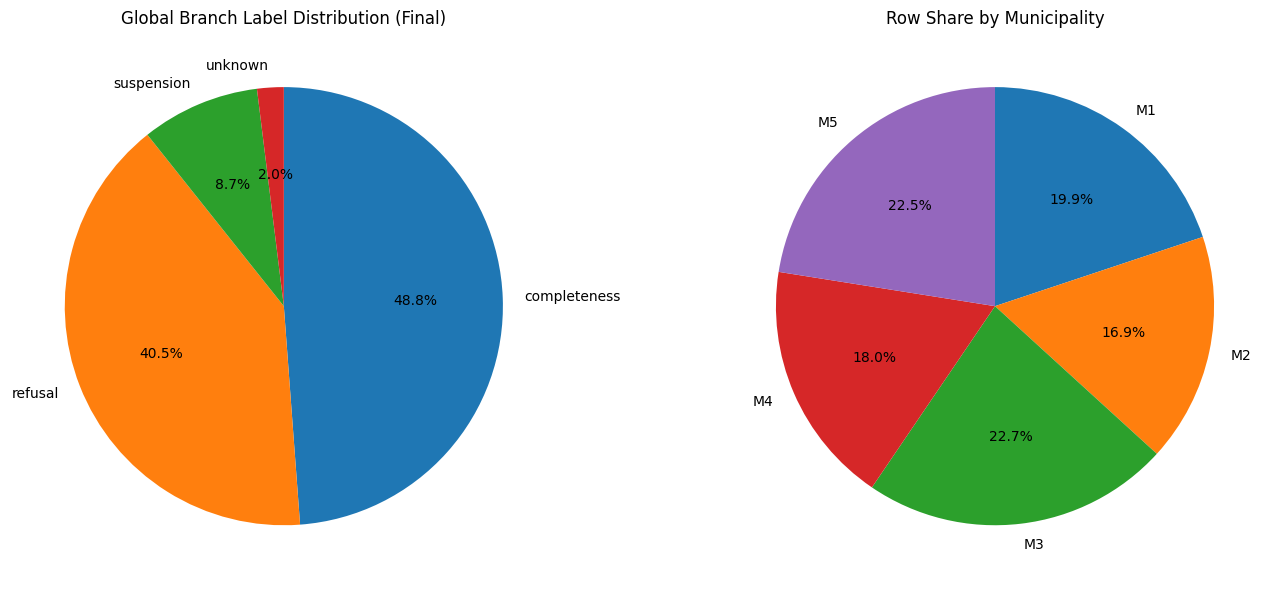

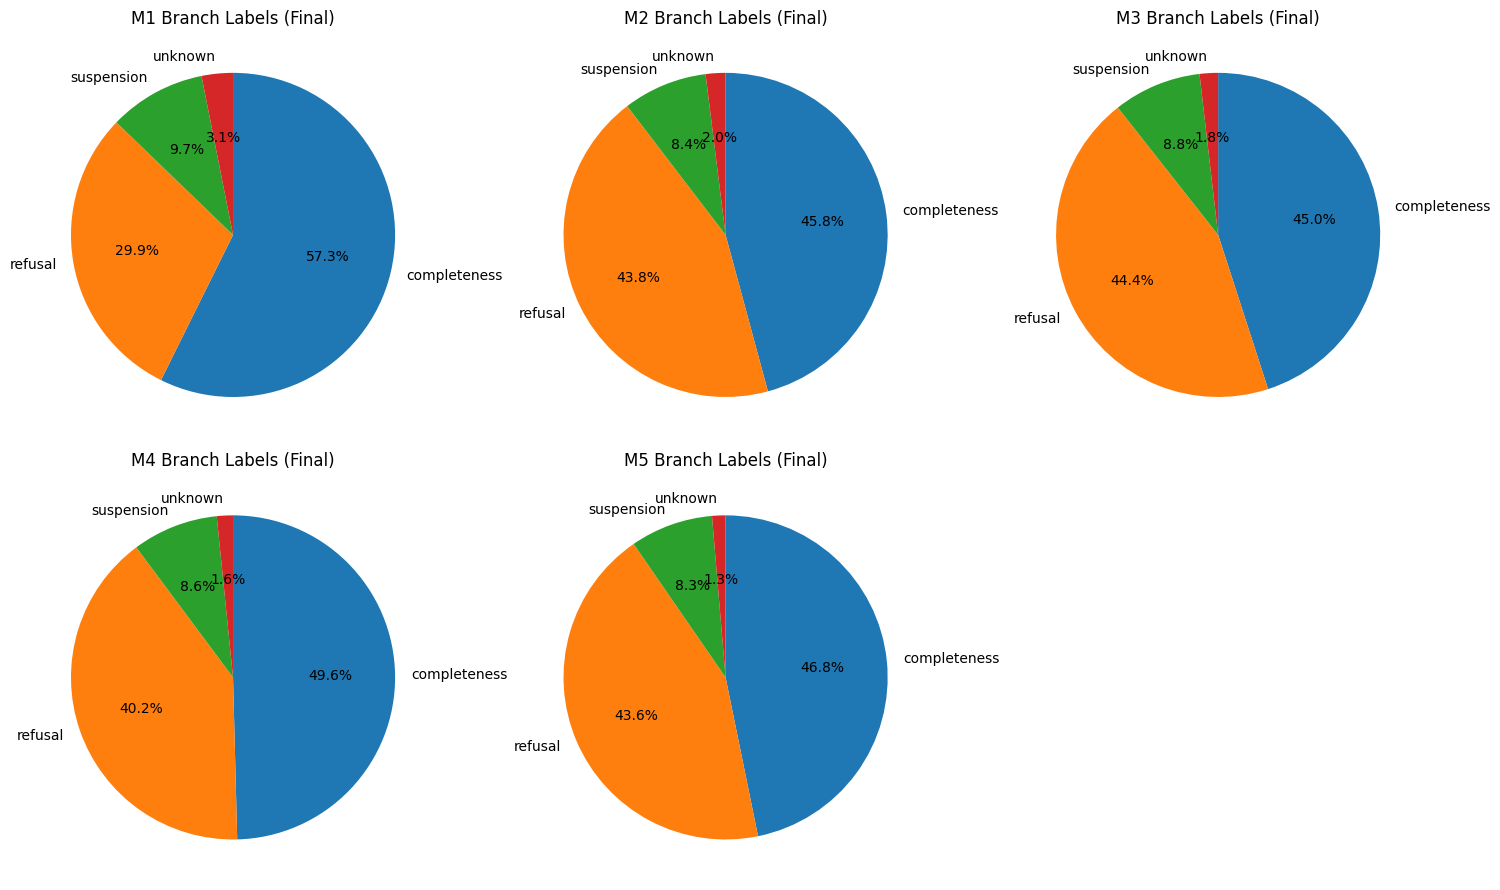

In [18]:
import math
import matplotlib.pyplot as plt

# Focus columns for quick interpretation
important_feature_cols = [
    'municipality', 'case_id', 'event_id', 'timestamp', 'activity',
    'step_index', 'trace_length', 'stage_rank',
    'time_since_case_start_hours', 'time_since_prev_hours',
    'rework_count_activity', 'seen_activity_before',
    'is_rare_transition_to_next', 'is_backbone_transition_to_next',
    'branch_label', 'branch_confidence', 'branch_source',
    'branch_label_final', 'branch_confidence_final', 'branch_source_final',
    'is_terminal_event', 'case_will_complete', 'case_completed'
 ]

# Keep only columns that exist (safe if schema changes slightly)
important_feature_cols = [c for c in important_feature_cols if c in features_df.columns]

# ---------- Row previews ----------
preview_n = 10

print('=== Global important feature rows (first 10) ===')
display(features_df[important_feature_cols].head(preview_n))

print('\n=== Important feature rows by municipality (first 10 each) ===')
for m in sorted(features_df['municipality'].dropna().unique()):
    print(f'\nMunicipality M{int(m)}')
    display(
        features_df.loc[features_df['municipality'] == m, important_feature_cols]
        .head(preview_n)
    )

# ---------- Pie charts: final branch-label distribution ----------
label_col = 'branch_label_final' if 'branch_label_final' in features_df.columns else 'branch_label'
branch_global = features_df[label_col].fillna('missing').value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global pie
axes[0].pie(
    branch_global.values,
    labels=branch_global.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
 )
axes[0].set_title('Global Branch Label Distribution (Final)')

# Municipality pie (share of rows by municipality)
m_counts = features_df['municipality'].value_counts().sort_index()
axes[1].pie(
    m_counts.values,
    labels=[f'M{int(m)}' for m in m_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
 )
axes[1].set_title('Row Share by Municipality')

plt.tight_layout()
plt.show()

# Per-municipality branch pies
municipalities = sorted(features_df['municipality'].dropna().unique())
n = len(municipalities)
cols = 3
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
axes = axes.flatten()

for idx, m in enumerate(municipalities):
    ax = axes[idx]
    counts = (
        features_df.loc[features_df['municipality'] == m, label_col]
        .fillna('missing')
        .value_counts()
    )
    ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False
    )
    ax.set_title(f'M{int(m)} Branch Labels (Final)')

# Hide any unused subplot axes
for j in range(len(municipalities), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [25]:
# Basic validation checks
dupes = features_df.duplicated(subset=['municipality', 'case_id', 'event_id']).sum()
neg_case = (features_df['time_since_case_start_hours'] < 0).sum()
neg_prev = (features_df['time_since_prev_hours'] < 0).sum()

span_ok = True
for (m, c), g in features_df.groupby(['municipality', 'case_id']):
    expected = list(range(len(g)))
    actual = g.sort_values('step_index')['step_index'].tolist()
    if expected != actual:
        span_ok = False
        break

final_label_col = 'branch_label_final' if 'branch_label_final' in features_df.columns else 'branch_label'
final_conf_col = 'branch_confidence_final' if 'branch_confidence_final' in features_df.columns else 'branch_confidence'
final_source_col = 'branch_source_final' if 'branch_source_final' in features_df.columns else 'branch_source'

unknown_rate = float((features_df[final_label_col] == 'unknown').mean())
high_conf_rate = float((features_df[final_conf_col] >= 0.70).mean())

print('Duplicate (municipality, case_id, event_id):', int(dupes))
print('Negative time_since_case_start_hours:', int(neg_case))
print('Negative time_since_prev_hours:', int(neg_prev))
print('Step index span check passed:', span_ok)
print('Unknown branch rate:', round(unknown_rate, 4))
print('High-confidence branch rate (>=0.70):', round(high_conf_rate, 4))

print('\nBranch source distribution:')
print(features_df[final_source_col].value_counts(dropna=False).to_string())

Duplicate (municipality, case_id, event_id): 0
Negative time_since_case_start_hours: 0
Negative time_since_prev_hours: 0
Step index span check passed: True
Unknown branch rate: 0.0196
High-confidence branch rate (>=0.70): 0.9519

Branch source distribution:
branch_source_final
supervised_fallback    139253
edge_model              77490
lookahead               40737
none                     5071
lookahead_ambiguous        77


In [26]:
# Save output (parquet preferred)
parquet_path = OUTPUT_DIR / 'case_step_features.parquet'
csv_path = OUTPUT_DIR / 'case_step_features.csv'

saved_format = None
saved_engine = None
last_parquet_error = None

for engine in ['pyarrow', 'fastparquet']:
    try:
        features_df.to_parquet(parquet_path, engine=engine, index=False)
        saved_format = 'parquet'
        saved_engine = engine
        print(f'Saved parquet using {engine}:', parquet_path.resolve())
        break
    except Exception as e:
        last_parquet_error = e
        print(f'Parquet save failed with {engine}:', str(e))

if saved_format is None:
    features_df.to_csv(csv_path, index=False)
    saved_format = 'csv'
    print('Fell back to CSV:', csv_path.resolve())
    if last_parquet_error is not None:
        print('Last parquet error was:', last_parquet_error)

Saved parquet using pyarrow: /home/praharsha/Desktop/bueracratic-workflow-analyzer/output/case_step_features.parquet


## Step 2 complete

The case-step feature table is ready for Step 3 calibration work.